# Audio Loading and Preprocessing Pipeline

## Purpose

This notebook validates the audio preprocessing pipeline for the Urban Noise Governance System.

The goal is to ensure that audio recordings can be successfully loaded, cleaned, normalized, and standardized before feature extraction and machine learning model training.

## Objectives

This notebook performs the following tasks:

1. Load audio recordings from the UrbanSound8K dataset.
2. Verify that the audio files can be read correctly.
3. Remove silent sections from recordings.
4. Normalize audio amplitudes.
5. Standardize audio length.
6. Visualize processed audio signals.

## Inputs

- UrbanSound8K audio files (.wav)

## Outputs

- Cleaned audio signals
- Waveform visualizations
- Validated preprocessing pipeline

## Expected Result

A standardized audio signal ready for feature extraction.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

## Step 1: Import Required Modules

This section imports all preprocessing functions developed for the project.

The functions are responsible for:

- Loading audio files
- Cleaning audio recordings
- Removing silence
- Standardizing duration

In [2]:
from preprocessing.audio_loader import load_audio
from preprocessing.cleaner import normalize_audio
from preprocessing.cleaner import remove_silence
from preprocessing.resampler import standardize_length

## Step 1: Import Required Modules

This section imports all preprocessing functions developed for the project.

The functions are responsible for:

- Loading audio files
- Cleaning audio recordings
- Removing silence
- Standardizing duration

In [6]:
from pathlib import Path

# Find first audio file in UrbanSound8K
audio_file = next(
    Path("../data/raw/UrbanSound8K").rglob("*.wav")
)

print("Using file:", audio_file)

audio, sr = load_audio(audio_file)

print("Sample Rate:", sr)
print("Audio Length:", len(audio))

Using file: ..\data\raw\UrbanSound8K\fold1\101415-3-0-2.wav
Sample Rate: 22050
Audio Length: 88200


## Step 3: Remove Silence

Environmental recordings often contain silent periods that do not contribute useful information.

Removing silence helps focus the model on meaningful acoustic events.

In [9]:
# Remove silent sections from audio
audio_no_silence = remove_silence(audio)

print("Length after silence removal:")
print(len(audio_no_silence))

Length after silence removal:
35328


## Step 4: Normalize Audio Signal

Audio recordings may have different volume levels.

Normalization scales all recordings to a consistent amplitude range, improving feature consistency.

In [10]:
# Normalize signal amplitude
normalized_audio = normalize_audio(audio_no_silence)

print("Maximum amplitude:")
print(normalized_audio.max())

Maximum amplitude:
0.9429332


## Step 5: Standardize Audio Length

Machine learning models require consistent input sizes.

This step ensures that all recordings have the same duration.

In [11]:
# Standardize recording length
processed_audio = standardize_length(normalized_audio)

print("Final shape:")
print(processed_audio.shape)

Final shape:
(88200,)


## Step 6: Visualize Processed Audio

The waveform visualization helps verify that preprocessing operations were applied correctly.

This also provides an initial understanding of the signal structure.

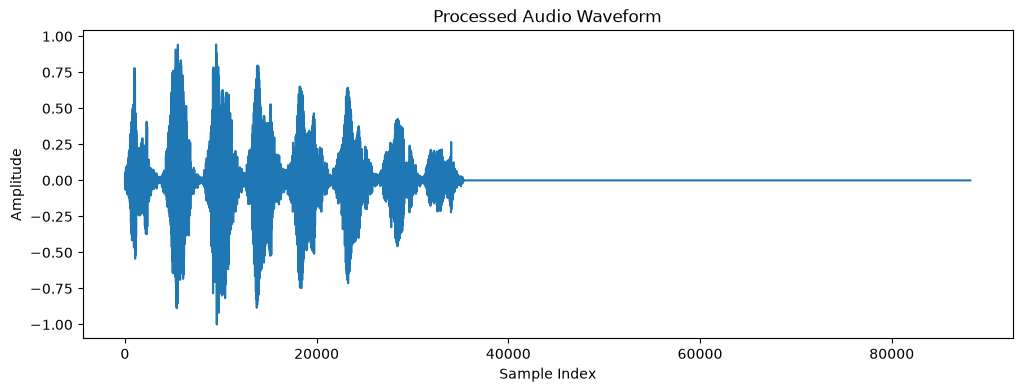

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(processed_audio)

plt.title("Processed Audio Waveform")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")

plt.show()

## Conclusion

The audio preprocessing pipeline has been validated.

The recording was successfully:

- Loaded
- Cleaned
- Normalized
- Standardized

The processed output is now ready for feature extraction in the next notebook.